In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

order_items_mart = pd.read_csv("../data/processed/order_items_mart.csv")

### Влияние логистики на удовлетворенность клиентов (CSAT)
1. Оценить глобальное влияние факта опоздания заказа на оценки пользователей.
2. Изучить деградацию клиентских оценок в зависимости от длительности задержки (в днях).
3. Выявить топ-5 самых проблемных штатов Бразилии по качеству и скорости доставки.

Глобальное влияние опозданий на отзывы:

In [2]:
delivered = order_items_mart[order_items_mart['order_status'] == 'delivered'].copy()

late_impact = delivered.groupby('is_late', as_index=False).agg(
    avg_review_score=('review_score', 'mean'),
    csat=('positive_review', 'mean'),
    orders_count=('order_id', 'nunique')
)

late_impact['is_late'] = late_impact['is_late'].map({False: 'Вовремя / Раньше срока', True: 'Опоздали с доставкой'})
display(late_impact)

,is_late,avg_review_score,csat,orders_count
0,Вовремя / Раньше срока,4.210220,0.803723,89171
1,Опоздали с доставкой,2.446274,0.315446,7307


График «Глубина опоздания»:

/var/folders/xm/js_cnpmd69z4d1bl71wrg3tm0000gn/T/ipykernel_75106/75086392.py:7: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  delay_degradation['delay_group'] = pd.Categorical(delay_degradation['delay_group'], categories=order_of_groups, ordered=True)


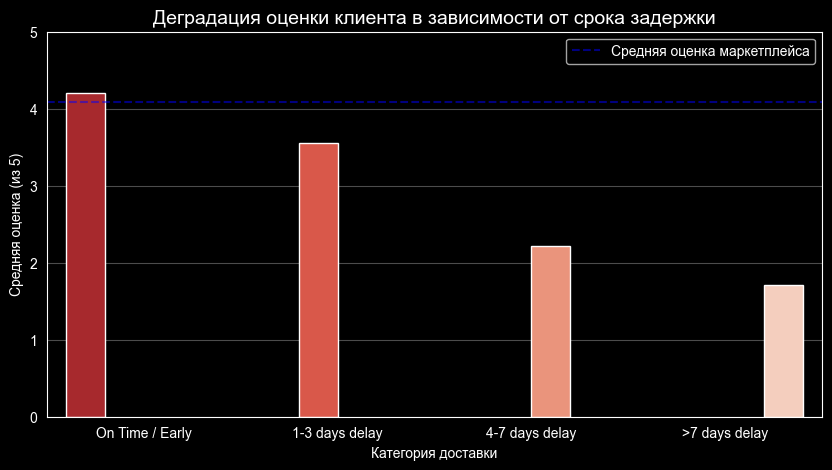

In [3]:
delay_degradation = delivered.groupby('delay_group', as_index=False).agg(
    avg_review=('review_score', 'mean'),
    orders_count=('order_id', 'nunique')
)

order_of_groups = ['On Time / Early', '1-3 days delay', '4-7 days delay', '>7 days delay']
delay_degradation['delay_group'] = pd.Categorical(delay_degradation['delay_group'], categories=order_of_groups, ordered=True)
delay_degradation = delay_degradation.sort_values('delay_group')

plt.figure(figsize=(10, 5))
sns.barplot(data=delay_degradation, x='delay_group', y='avg_review', hue='delay_group', palette='Reds_r', legend=False)

plt.axhline(y=delivered['review_score'].mean(), color='blue', linestyle='--', alpha=0.5, label='Средняя оценка маркетплейса')

plt.title('Деградация оценки клиента в зависимости от срока задержки', fontsize=14)
plt.xlabel('Категория доставки')
plt.ylabel('Средняя оценка (из 5)')
plt.ylim(0, 5)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Анализ проблемных регионов:

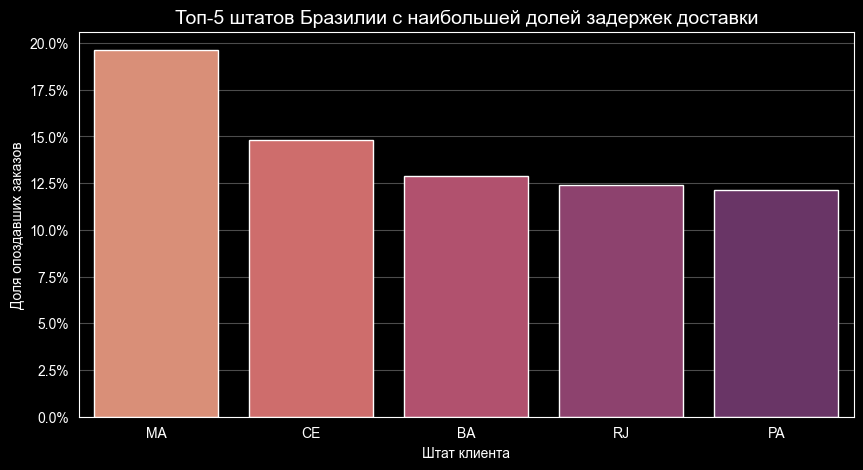

,customer_state,avg_delivery_days,late_rate,orders_count
9,MA,21.203750,0.196250,717
5,CE,20.537167,0.147966,1279
4,BA,18.774640,0.128971,3256
18,RJ,14.688821,0.124160,12350
13,PA,23.301708,0.121442,946


In [4]:
state_logistics = delivered.groupby('customer_state', as_index=False).agg(
    avg_delivery_days=('delivery_days', 'mean'),
    late_rate=('is_late', 'mean'),
    orders_count=('order_id', 'nunique')
)

state_logistics = state_logistics[state_logistics['orders_count'] >= 500]
worst_states = state_logistics.sort_values('late_rate', ascending=False).head(5)

plt.figure(figsize=(10, 5))
sns.barplot(data=worst_states, x='customer_state', y='late_rate', hue='customer_state', palette='flare', legend=False)
plt.title('Топ-5 штатов Бразилии с наибольшей долей задержек доставки', fontsize=14)
plt.xlabel('Штат клиента')
plt.ylabel('Доля опоздавших заказов')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(axis='y', alpha=0.3)
plt.show()

display(worst_states[['customer_state', 'avg_delivery_days', 'late_rate', 'orders_count']])

### Итоги анализа логистики:
1. Заказы, доставленные вовремя или раньше срока, имеют средний CSAT около **80%** и средний балл выше 4.2. Но как только происходит факт опоздания, оценка падает до 2.2-2.4 баллов, а при задержке более чем на неделю клиенты массово ставят 1 звезду.
2. В отдаленных штатах (например, `AL`, `MA`) доля опозданий достигает критических **20-30%**, а средний срок доставки превышает 20-25 дней.
3. **Бизнес-рекомендации:** * Отделу логистики необходимо пересмотреть контракты с курьерскими службами в проблемных штатах.
   * На сайте маркетплейса нужно динамически увеличить закладываемое «ожидаемое время доставки» для северных регионов, чтобы не обманывать ожидания клиентов (клиент менее агрессивен, если ему сразу пообещали везти товар 25 дней, чем если пообещали за 10, а привезли за 15).